In [53]:
import cv2
import numpy as np
import rasterio
from rasterio.transform import Affine
from pyproj import CRS, Transformer
from pyproj import Geod
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
import json
from skimage.draw import line

fpath = "Data/NDVI.data.tif"

ndvi, profile, transform, crs = None, None, None, None

In [ ]:
with rasterio.open(fpath) as src:
    ndvi = src.read(1) 

    profile = src.profile
    transform = src.transform
    crs = src.crs

In [55]:
xmin, ymin = transform * (0, 0)
xmax, ymax = transform * (src.width, src.height)
height_px, width_px = ndvi.shape[0], ndvi.shape[1]

print(f"Bounding box in UTM: ({xmin}, {ymin}) to ({xmax}, {ymax})")

Bounding box in UTM: (489041.0228945217, 1805088.1163430738) to (489151.6696408869, 1804873.5769851631)


In [56]:
utm_crs = CRS.from_epsg(32644)
wgs84_crs = CRS.from_epsg(4326)

transformer = Transformer.from_crs(utm_crs, wgs84_crs, always_xy=True)

lon_min, lat_min = transformer.transform(xmin, ymin)
lon_max, lat_max = transformer.transform(xmax, ymax)

print(f"Top Left:\t({lat_min}, {lon_min})\nBottom Right:\t({lat_max}, {lon_max})")

Top Left:	(16.326805747535087, 80.89740320760403)
Bottom Right:	(16.32486678659248, 80.89844007039832)


In [57]:
colors = [(0,0,0), (1,1,1)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list("white_black", colors, N=n_bins)

norm = Normalize(vmin=-1, vmax=1)

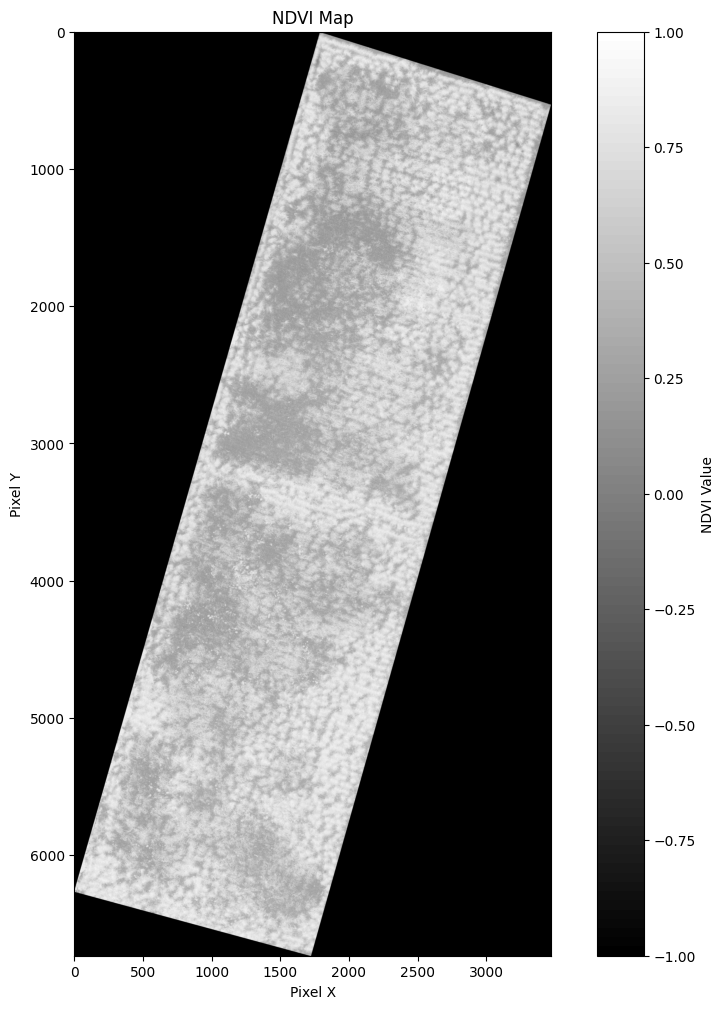

In [58]:
plt.figure(figsize=(12, 12))
img = plt.imshow(ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')

plt.title('NDVI Map')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.imshow(np.ma.masked_less(ndvi, -1), cmap=cmap, norm=norm)

plt.show()

In [59]:
geod = Geod(ellps="WGS84")
_, _, width_meters = geod.inv(lon_min, lat_min, lon_max, lat_min)
_, _, height_meters = geod.inv(lon_min, lat_min, lon_min, lat_max)

Spray radius: 5m

In [60]:
print(f"ratio_meters: {height_meters/width_meters}, ratio_px: {height_px/width_px}") #readings verified

ratio_meters: 1.9365858988861402, ratio_px: 1.9389576734811402


In [61]:
spray_radius = 5    #m
chunk_dim = max(1, round(height_px * spray_radius / height_meters))
num_chunks_V = np.ceil(height_meters / spray_radius)
num_chunks_H = np.ceil(width_meters / spray_radius)

chunk_V_bounds = range(0, height_px, chunk_dim)
chunk_H_bounds = range(0, width_px, chunk_dim)
chunk_bounds = (chunk_V_bounds, chunk_H_bounds)

chunk_lat_boundaries = np.linspace(lat_min, lat_max, int(num_chunks_V + 1))
chunk_lon_boundaries = np.linspace(lon_min, lon_max, int(num_chunks_H + 1))

def pixel_coord_to_chunk_coord(y, x, _chunk_dim=chunk_dim):
    chunk_x = x // _chunk_dim
    chunk_y = y // _chunk_dim
    return chunk_y, chunk_x

def chunk_coord_to_geo_coord(y, x,
                             y_offset=0,
                             x_offset=0,
                            _chunk_latlon_boundaries=(chunk_lat_boundaries, chunk_lon_boundaries) ):
    return _chunk_latlon_boundaries[0][y]+y_offset, _chunk_latlon_boundaries[1][x]+x_offset

def pixel_coord_to_geo_coord(y, x):
    cy, cx = pixel_coord_to_chunk_coord(y, x)
    return chunk_coord_to_geo_coord(cy, cx)

def get_chunk(chunk_y, chunk_x, img=ndvi, _chunk_bounds=chunk_bounds, _chunk_dim=chunk_dim):

    chunk_bounds_y, chunk_bounds_x = _chunk_bounds[0], _chunk_bounds[1]
    start_y, start_x = chunk_bounds_y[chunk_y], chunk_bounds_x[chunk_x]
    end_y, end_x = start_y + _chunk_dim, start_x + _chunk_dim

    img_slice = img[start_y:end_y, start_x:end_x]

    return img_slice

def chunk_coord_to_pixel_coord(cy, cx, _chunk_dim=chunk_dim):
    return np.array([cy * _chunk_dim, cx * _chunk_dim])

In [62]:
infected_chunks = []
infection_cutoff = 0.5

for chunk_y in range(len(chunk_bounds[0])):
    for chunk_x in range(len(chunk_bounds[1])):
        chunk = get_chunk(chunk_y, chunk_x)

        if chunk.size == 0:
            continue

        chunk = np.ma.masked_equal(chunk, -10000)
        chunk_avg = chunk.mean()

        if chunk_avg < infection_cutoff:
            infected_chunks.append((chunk_y, chunk_x, chunk_avg))

print(f"Total infected chunks: {len(infected_chunks)}")
print(infected_chunks)


Total infected chunks: 154
[(0, 14, np.float64(0.2951583624628845)), (1, 16, np.float64(0.4348382105990813)), (1, 17, np.float64(0.22485429918443833)), (2, 11, np.float32(0.44636986)), (2, 12, np.float32(0.44116595)), (2, 13, np.float32(0.45137456)), (2, 14, np.float32(0.3813884)), (2, 20, np.float64(0.40731706968338216)), (3, 12, np.float32(0.43933982)), (3, 13, np.float32(0.47453272)), (3, 14, np.float32(0.44372562)), (3, 15, np.float32(0.49590093)), (3, 22, np.float64(0.3232138111415936)), (4, 12, np.float32(0.3513628)), (4, 13, np.float32(0.34989032)), (4, 14, np.float32(0.40203515)), (4, 15, np.float32(0.48251674)), (5, 12, np.float32(0.44608775)), (5, 21, np.float64(0.4986963441630275)), (6, 11, np.float32(0.44507527)), (6, 12, np.float32(0.4398402)), (6, 21, np.float64(0.4046914753294962)), (7, 11, np.float32(0.4030305)), (7, 12, np.float32(0.4328066)), (7, 13, np.float32(0.45075458)), (7, 21, np.float64(0.35511384186921297)), (8, 10, np.float32(0.45022276)), (8, 11, np.float32(

In [63]:
infected_coords = []

for chunk_y, chunk_x, avg in infected_chunks:
    corners_latlon = chunk_coord_to_geo_coord(chunk_y, chunk_x)
    
    infected_coords.append({
        "chunk_index": [chunk_y, chunk_x],
        "coordinates": corners_latlon,
        "value": float(avg)
    })

with open("Data/infected.json", "w") as f:
    json.dump(infected_coords, f, indent=4)

print(f"Saved {len(infected_coords)} chunks to infected.json")


Saved 154 chunks to infected.json


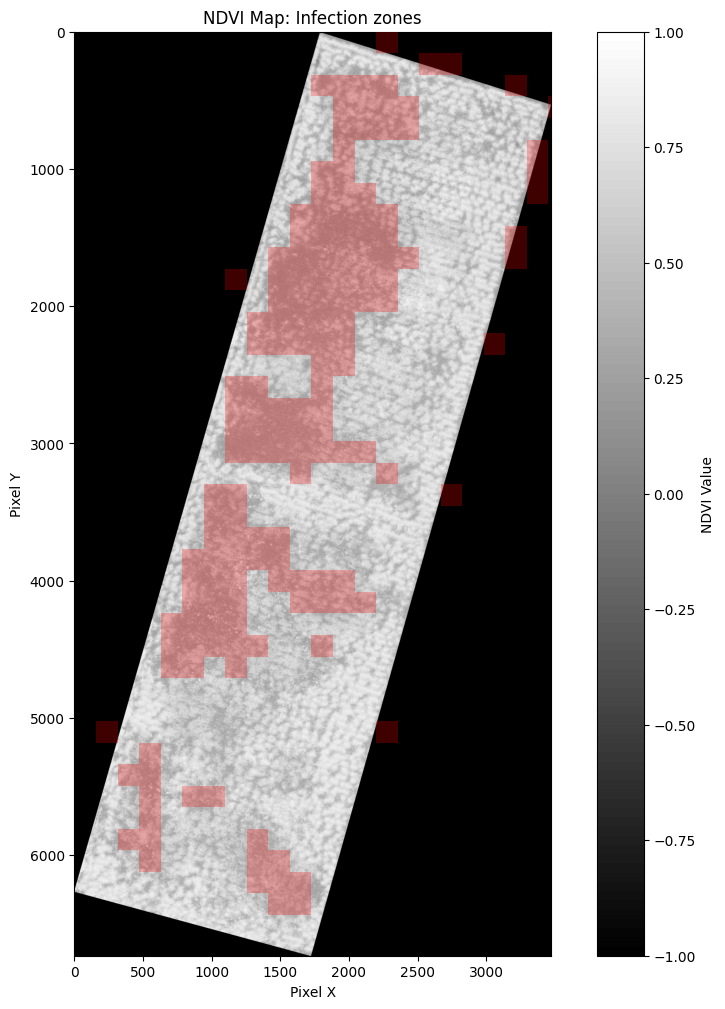

In [64]:
plt.figure(figsize=(12, 12))

img = plt.imshow(ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')
plt.imshow(np.ma.masked_less(ndvi, -1), cmap=cmap, norm=norm)

for chunk_y, chunk_x, infection_level in infected_chunks:
    start_y = chunk_y * chunk_dim
    start_x = chunk_x * chunk_dim
    
    height = min(chunk_dim, ndvi.shape[0] - start_y)
    width = min(chunk_dim, ndvi.shape[1] - start_x)
    
    alpha = 0.25
    
    rect = patches.Rectangle(
        (start_x, start_y),
        width,
        height,
        linewidth=0,
        edgecolor=None,
        facecolor=(1, 0, 0, alpha),
        zorder=3
    )
    
    plt.gca().add_patch(rect)

plt.title('NDVI Map: Infection zones')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.show()

In [ ]:
chkp0_chunk_coords = (39, 0)
chkp1_chunk_coords = (0, 11)
chkp2_chunk_coords = (42, 10)
chkp3_chunk_coords = (3,22)

p0 = chunk_coord_to_pixel_coord(chkp0_chunk_coords[0], chkp0_chunk_coords[1]) + chunk_dim/2
p1 = chunk_coord_to_pixel_coord(chkp1_chunk_coords[0], chkp1_chunk_coords[1]) + chunk_dim/2
p3 = chunk_coord_to_pixel_coord(chkp3_chunk_coords[0], chkp3_chunk_coords[1]) + chunk_dim/2

v_primary = p1 - p0
v_step = p3 - p1

length_primary = np.linalg.norm(v_primary)
length_step = np.linalg.norm(v_step)

unit_primary = v_primary / length_primary
unit_step = v_step / length_step

step_size = chunk_dim * 2
num_steps = int(length_step // step_size)

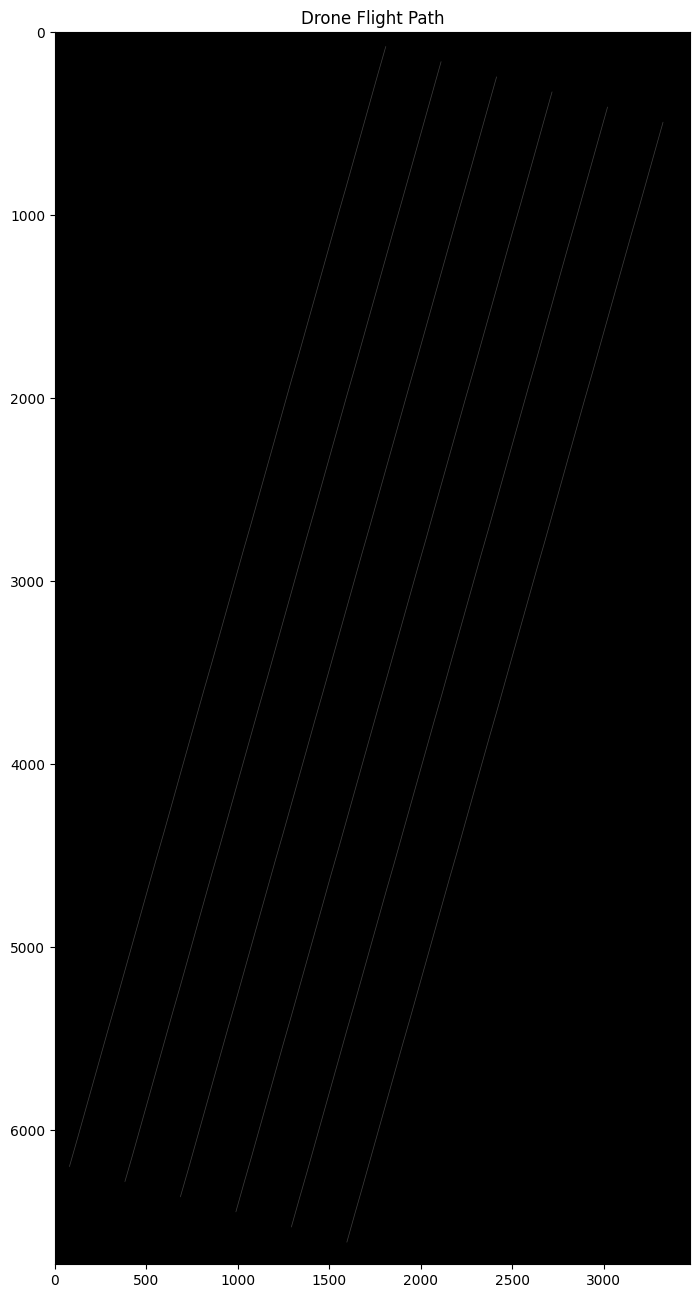

In [69]:
from skimage.draw import line  # skimage is great for pixel-level drawing

spray_zone = np.zeros_like(ndvi)

for i in range(num_steps + 1):
    offset = unit_step * (i * step_size)
    start = p0 + offset
    end = p1 + offset

    sweep_length = np.linalg.norm(end - start)
    num_chunks_along = int(sweep_length // chunk_dim)
    
    if i % 2 == 0:
        direction = 1
    else:
        direction = -1

    prev_point = None
    for j in range(num_chunks_along + 1):
        t = j / num_chunks_along if direction == 1 else 1 - (j / num_chunks_along)
        point = start * (1 - t) + end * t
        y, x = int(round(point[0])), int(round(point[1]))

        if prev_point is not None:
            rr, cc = line(prev_point[0], prev_point[1], y, x)
            rr = np.clip(rr, 0, spray_zone.shape[0] - 1)
            cc = np.clip(cc, 0, spray_zone.shape[1] - 1)
            spray_zone[rr, cc] = 1
        else:
            if 0 <= y < spray_zone.shape[0] and 0 <= x < spray_zone.shape[1]:
                spray_zone[y, x] = 1

        prev_point = (y, x)

plt.figure(figsize=(10,16))
plt.imshow(spray_zone, cmap="gray")
plt.title("Drone Flight Path")
plt.show()